<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/DL_day3/3_2_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/binsue0/.github/blob/main/DL_day3/3_2_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 규제(Regularization) 기법 — FashionMNIST 실습

같은 신경망에 **세 가지 세팅**을 학습시켜 loss 곡선을 비교합니다.

| 모델 | 추가한 것 | 노리는 효과 |
|---|---|---|
| **Net** | 없음 (기본) | 비교 기준 |
| **NetBN** | Batch Normalization | Internal Covariate Shift 완화 → 학습 안정·가속 |
| **NetDO** | Dropout | 과적합(Overfitting) 방지 |


## 1. 준비 — 라이브러리 & FashionMNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from torchsummary import summary

In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.7MB/s]


In [3]:
batch_size = 32

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_data,  batch_size=batch_size, shuffle=True)

Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


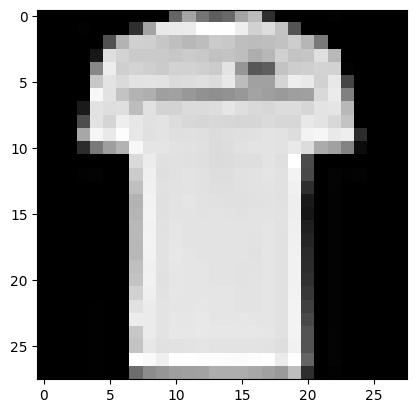

Label: 0 (labels_map[int(label)])


In [4]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label} (labels_map[int(label)])")

## 2. 세 가지 모델 정의

구조는 동일한 4층 MLP. **BN은 `bn` 층 추가**, **DO는 `dropout` 층 추가**만 다릅니다.
forward에서 어디에 끼어드는지 비교해 보세요.

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

In [6]:
class NetBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.bn1 = nn.BatchNorm1d(2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.bn2 = nn.BatchNorm1d(2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)

    def forward(self, x):
        # same as torch.flatten(x,1)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

In [7]:
class NetDO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 2**8)
        self.fc2 = nn.Linear(2**8, 2**6)
        self.fc3 = nn.Linear(2**6, 2**5)
        self.fc4 = nn.Linear(2**5, 10)
        self.dropout1 = nn.Dropout(p=0.8)
        self.dropout2 = nn.Dropout(p=0.5)

    def forward(self, x):
        # same as x.view(x.size(0), -1)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = F.softmax(x, dim=1)
        return x

## 3. 학습 설정

세 모델 각각에 동일한 손실함수(CrossEntropy)·옵티마이저(Adam)·스케줄러(StepLR)를 붙입니다.
`StepLR`은 step_size 에폭마다 gamma 비율로 learning rate를 낮춥니다.

In [8]:
num_epochs = 5   # 발표용 (원본 20)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda:0


In [9]:
net_nn, net_bn, net_do = Net(), NetBN(), NetDO()
criterion = nn.CrossEntropyLoss()

optimizer_nn = optim.Adam(net_nn.parameters(), lr=0.001)
optimizer_bn = optim.Adam(net_bn.parameters(), lr=0.001)
optimizer_do = optim.Adam(net_do.parameters(), lr=0.001)

scheduler_nn = optim.lr_scheduler.StepLR(optimizer_nn, step_size=5, gamma=0.8)
scheduler_bn = optim.lr_scheduler.StepLR(optimizer_bn, step_size=5, gamma=0.8)
scheduler_do = optim.lr_scheduler.StepLR(optimizer_do, step_size=5, gamma=0.8)

### 학습 함수

매 에폭: train 모드로 학습 → eval 모드로 test loss·accuracy 측정. train/test loss 리스트를 반환해 나중에 그래프로 그립니다.

**포인트:** BN·Dropout은 `net.train()` / `net.eval()`에 따라 동작이 달라지므로 모드 전환이 중요합니다.

In [10]:
def train(net, optimizer, scheduler, path_name):

    train_losses, test_losses = [], []

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        # set train mode
        net.train()

        # training
        running_loss = 0.0

        for inputs, labels in train_dataloader:

            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            outputs = net(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        # adjust learning rate with scheduler
        scheduler.step()


        # evaluation(validation)
        test_loss = 0.0
        accuracy = 0.0

        # turn off grardients for validation
        with torch.no_grad():

            # set evaluation (test) mode
            net.eval()

            for inputs, labels in test_dataloader:

                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)

                test_loss += criterion(outputs, labels)

                # 로그 확률에 지수 적용
                ps = torch.exp(outputs)

                # topk는 k번째로 큰 숫자를 찾아내는 것
                # dim=1 는 dimension을 의미
                top_p, top_class = ps.topk(1, dim=1)


                # labels를 top_class와 똑같은 형태로 만든다음에, 얼마나 같은게 있는지 확인한다.
                equals = top_class == labels.view(*top_class.shape)


                # equals를 float으로 바꾸고 평균 정확도를 구한다.
                accuracy += torch.mean(equals.type(torch.FloatTensor))


        test_accuracy = accuracy / len(test_dataloader)

        current_train_loss = running_loss / len(train_dataloader)
        current_test_loss = test_loss / len(test_dataloader)

        train_losses.append(current_train_loss)
        test_losses.append(current_test_loss.detach().cpu().numpy())

        print(
            f"Epoch: {epoch+1} / {num_epochs}..",
            "Training Loss: {:.5f}..  ".format(current_train_loss),
            "Test Loss: {:.5f}..  ".format(current_test_loss),
            "Test Accuracy: {:.3f}".format(test_accuracy)

        )

    # save trained model
    PATH = f'./{path_name}.pth'
    torch.save(net.state_dict(), PATH)

    return train_losses, test_losses

## 4. 학습 & 비교

### (1) 기본 모델 (규제 없음)

In [11]:
net_nn = net_nn.to(device)
train_loss_nn, test_loss_nn = train(net_nn, optimizer_nn, scheduler_nn, 'FMNIST_nn')

Epoch: 1 / 5.. Training Loss: 1.76602..   Test Loss: 1.70947..   Test Accuracy: 0.752
Epoch: 2 / 5.. Training Loss: 1.68533..   Test Loss: 1.69049..   Test Accuracy: 0.770
Epoch: 3 / 5.. Training Loss: 1.67595..   Test Loss: 1.67588..   Test Accuracy: 0.783
Epoch: 4 / 5.. Training Loss: 1.66869..   Test Loss: 1.67158..   Test Accuracy: 0.789
Epoch: 5 / 5.. Training Loss: 1.66615..   Test Loss: 1.66555..   Test Accuracy: 0.795


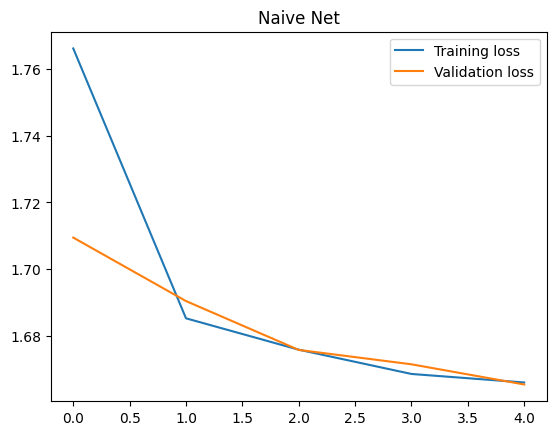

In [12]:
plt.plot(train_loss_nn, label='Training loss')
plt.plot(test_loss_nn, label='Validation loss')
plt.legend(); plt.title('Naive Net'); plt.show()

### (2) Batch Normalization

In [13]:
net_bn = net_bn.to(device)
train_loss_bn, test_loss_bn = train(net_bn, optimizer_bn, scheduler_bn, 'FMNIST_bn')

Epoch: 1 / 5.. Training Loss: 1.68001..   Test Loss: 1.62132..   Test Accuracy: 0.843
Epoch: 2 / 5.. Training Loss: 1.62004..   Test Loss: 1.61224..   Test Accuracy: 0.850
Epoch: 3 / 5.. Training Loss: 1.60487..   Test Loss: 1.60882..   Test Accuracy: 0.851
Epoch: 4 / 5.. Training Loss: 1.59528..   Test Loss: 1.62238..   Test Accuracy: 0.839
Epoch: 5 / 5.. Training Loss: 1.59157..   Test Loss: 1.59401..   Test Accuracy: 0.868


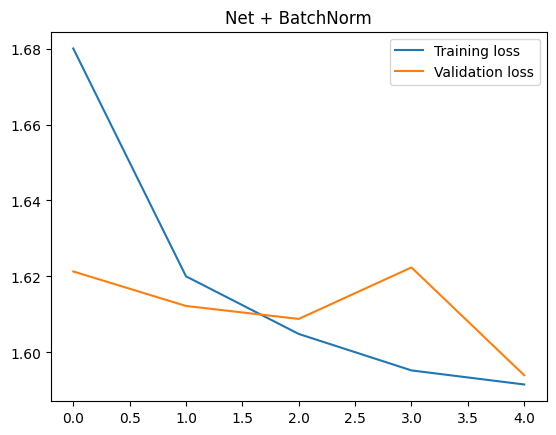

In [14]:
plt.plot(train_loss_bn, label='Training loss')
plt.plot(test_loss_bn, label='Validation loss')
plt.legend(); plt.title('Net + BatchNorm'); plt.show()

### (3) Dropout

In [15]:
net_do = net_do.to(device)
train_loss_do, test_loss_do = train(net_do, optimizer_do, scheduler_do, 'FMNIST_do')

Epoch: 1 / 5.. Training Loss: 1.87759..   Test Loss: 1.74649..   Test Accuracy: 0.711
Epoch: 2 / 5.. Training Loss: 1.75626..   Test Loss: 1.68964..   Test Accuracy: 0.769
Epoch: 3 / 5.. Training Loss: 1.73509..   Test Loss: 1.67461..   Test Accuracy: 0.787
Epoch: 4 / 5.. Training Loss: 1.72304..   Test Loss: 1.66362..   Test Accuracy: 0.798
Epoch: 5 / 5.. Training Loss: 1.71619..   Test Loss: 1.66294..   Test Accuracy: 0.798


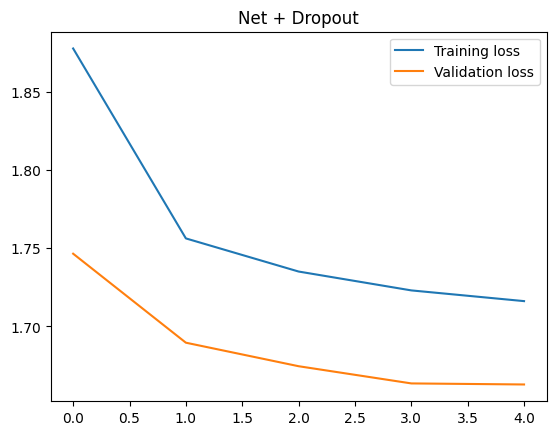

In [16]:
plt.plot(train_loss_do, label='Training loss')
plt.plot(test_loss_do, label='Validation loss')
plt.legend(); plt.title('Net + Dropout'); plt.show()

### 세 모델 한눈에 비교

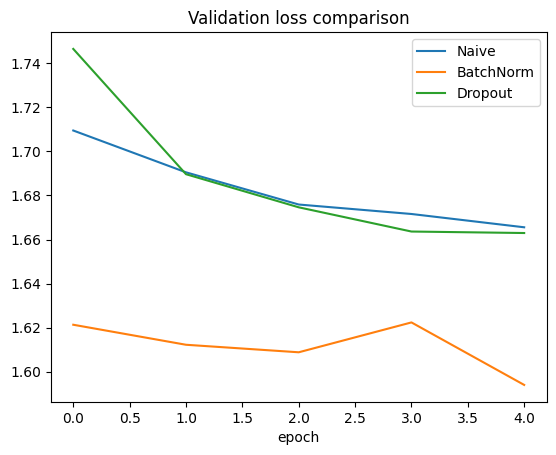

In [17]:
plt.plot(test_loss_nn, label='Naive')
plt.plot(test_loss_bn, label='BatchNorm')
plt.plot(test_loss_do, label='Dropout')
plt.legend(); plt.title('Validation loss comparison'); plt.xlabel('epoch'); plt.show()

## 정리

- **Batch Normalization:** 층 입력 분포를 정규화 → 학습이 더 빠르고 안정적으로 수렴
- **Dropout:** 학습 중 뉴런을 랜덤하게 꺼서 특정 뉴런 의존을 막음 → 과적합 억제
- 두 기법 모두 `train()`/`eval()` 모드에서 **동작이 달라진다**는 점이 핵심